# Project 5: Basic Natural Language Processing with Unsupervised Learning

**Name:** OBAJE PAUL  
**Course:** MACHINE LEARNING

## Project Overview
In this project, I apply basic Natural Language Processing techniques to the 20 Newsgroups dataset. I clean and prepare the documents, represent text using Bag of Words and TF-IDF, illustrate basic word embeddings, and use K-Means clustering to discover topics without using category labels during training.

I then interpret the clusters using important terms, evaluate the clustering, assign unseen documents to learned clusters, and visualize the document groups in two dimensions.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Text Data Preparation

I load the 20 Newsgroups dataset directly through Scikit-learn. I remove headers, footers and quoted replies so the clustering focuses more on the message content. The original category labels are retained only for exploration and validation; they are not used to train K-Means.


In [2]:
# Load the 20 Newsgroups dataset using Scikit-learn

from sklearn.datasets import fetch_20newsgroups

remove_parts = ("headers", "footers", "quotes")

train_data = fetch_20newsgroups(
    subset="train",
    remove=remove_parts,
    shuffle=True,
    random_state=42,
    download_if_missing=True
)

test_data = fetch_20newsgroups(
    subset="test",
    remove=remove_parts,
    shuffle=True,
    random_state=42,
    download_if_missing=True
)

print("Training documents:", len(train_data.data))
print("Test documents:", len(test_data.data))
print("Number of categories:", len(train_data.target_names))

Training documents: 11314
Test documents: 7532
Number of categories: 20


In [3]:
print("Categories:")
for name in train_data.target_names:
    print("-", name)

print("\nExample document:")
print(train_data.data[0][:1200])


Categories:
- alt.atheism
- comp.graphics
- comp.os.ms-windows.misc
- comp.sys.ibm.pc.hardware
- comp.sys.mac.hardware
- comp.windows.x
- misc.forsale
- rec.autos
- rec.motorcycles
- rec.sport.baseball
- rec.sport.hockey
- sci.crypt
- sci.electronics
- sci.med
- sci.space
- soc.religion.christian
- talk.politics.guns
- talk.politics.mideast
- talk.politics.misc
- talk.religion.misc

Example document:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


### Basic preprocessing

I convert text to lowercase and remove punctuation, numbers and unnecessary whitespace. Tokenization and English stopword removal are handled by Scikit-learn's vectorizers when I create the Bag of Words and TF-IDF matrices.


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_train = [clean_text(doc) for doc in train_data.data]
clean_test = [clean_text(doc) for doc in test_data.data]

print("Original example:")
print(train_data.data[0][:500])
print("\nCleaned example:")
print(clean_train[0][:500])


Original example:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Cleaned example:
i was wondering if anyone out there could enlighten me on this car i saw the other day it was a door sports car looked to be from the late s early s it was called a bricklin the doors were really small in addition the front bumper was separate from the rest of the body this is all i know if anyone can tellme a model name engine specs years of production where this car is made history or whatever info you have on this funky looking car please e mail


Training documents: 11314
Average words per document: 204.16
Median words per document: 84.0
Shortest document: 0
Longest document: 15497


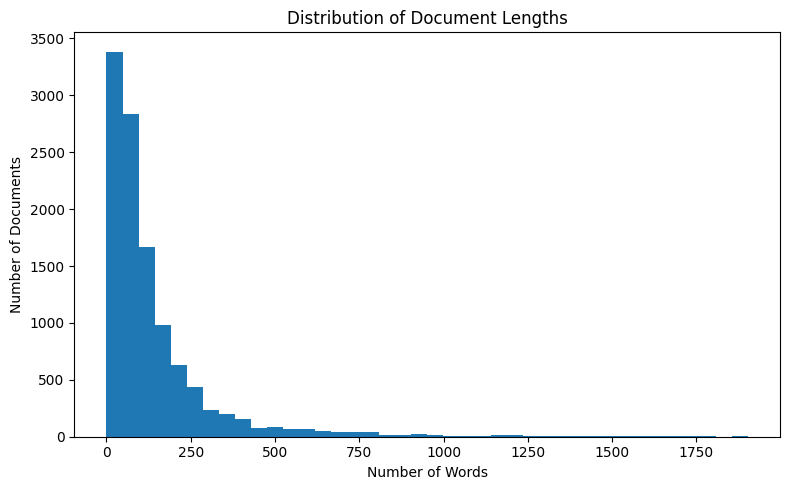

In [5]:
lengths = np.array([len(doc.split()) for doc in clean_train])

print("Training documents:", len(clean_train))
print("Average words per document:", round(lengths.mean(), 2))
print("Median words per document:", round(np.median(lengths), 2))
print("Shortest document:", lengths.min())
print("Longest document:", lengths.max())

plt.figure(figsize=(8, 5))
plt.hist(lengths[lengths < np.percentile(lengths, 99)], bins=40)
plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.title("Distribution of Document Lengths")
plt.tight_layout()
plt.show()


## 2. Text Representation

### Bag of Words
Bag of Words represents a document using counts of the words that appear in it. I remove common English stopwords and ignore extremely rare or extremely common terms.


In [6]:
bow_vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.80,
    min_df=5,
    max_features=10000
)

X_bow = bow_vectorizer.fit_transform(clean_train)

print("Bag of Words matrix shape:", X_bow.shape)
print("Vocabulary size:", len(bow_vectorizer.get_feature_names_out()))


Bag of Words matrix shape: (11314, 10000)
Vocabulary size: 10000


In [7]:
word_counts = np.asarray(X_bow.sum(axis=0)).ravel()
terms = bow_vectorizer.get_feature_names_out()
top_ids = word_counts.argsort()[-20:][::-1]

top_words = pd.DataFrame({
    "word": terms[top_ids],
    "count": word_counts[top_ids]
})
display(top_words)


,word,count
0,ax,62485
1,max,4680
2,people,4104
3,like,3967
4,don,3886
5,just,3757
6,know,3492
7,use,3181
8,think,3014
9,time,2977


### TF-IDF
TF-IDF gives more weight to words that are important to a particular document while reducing the influence of terms that occur in many documents. I use TF-IDF for the main clustering model.


In [8]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.80,
    min_df=5,
    max_features=10000,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(clean_train)
X_test_tfidf = tfidf_vectorizer.transform(clean_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (11314, 10000)
Test TF-IDF shape: (7532, 10000)


### Basic word-embedding illustration
A word embedding represents words as dense numerical vectors so that semantic similarity can be expressed numerically. A full pre-trained embedding requires an additional model download, so I include a small self-contained vector example to illustrate the idea. The same cosine-similarity principle can be applied to pre-trained Word2Vec or GloVe vectors.


In [9]:
example_embeddings = {
    "computer": np.array([0.90, 0.10, 0.15]),
    "software": np.array([0.85, 0.12, 0.18]),
    "space": np.array([0.10, 0.92, 0.20]),
    "orbit": np.array([0.08, 0.88, 0.25])
}

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("computer vs software:",
      round(cosine_similarity(example_embeddings["computer"],
                              example_embeddings["software"]), 3))
print("computer vs space:",
      round(cosine_similarity(example_embeddings["computer"],
                              example_embeddings["space"]), 3))


computer vs software: 0.999
computer vs space: 0.244


## 3. Unsupervised Learning with K-Means

The dataset contains 20 known newsgroup categories, but I do not give those labels to K-Means. I use 20 clusters as an interpretable configuration and examine whether the discovered groups contain meaningful topic words.


In [10]:
n_clusters = 20

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10,
    max_iter=300
)

train_clusters = kmeans.fit_predict(X_train_tfidf)

print("K-Means clustering completed.")
print("Number of clusters:", n_clusters)
print("Inertia:", round(kmeans.inertia_, 2))


K-Means clustering completed.
Number of clusters: 20
Inertia: 10563.62


,documents
0,550
1,1011
2,583
3,72
4,3423
5,400
6,395
7,258
8,405
9,20


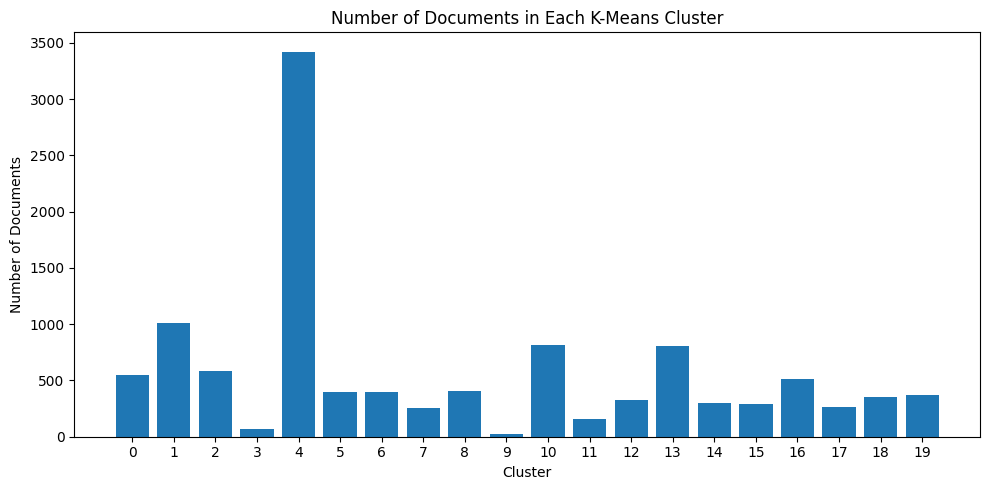

In [11]:
cluster_sizes = pd.Series(train_clusters).value_counts().sort_index()
display(cluster_sizes.to_frame("documents"))

plt.figure(figsize=(10, 5))
plt.bar(cluster_sizes.index, cluster_sizes.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Documents")
plt.title("Number of Documents in Each K-Means Cluster")
plt.xticks(range(n_clusters))
plt.tight_layout()
plt.show()


### Cluster interpretation

I inspect the terms with the largest centroid weights in each cluster. These words help reveal the common theme represented by each group.


In [12]:
terms = tfidf_vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

for cluster_id in range(n_clusters):
    top_ids = centers[cluster_id].argsort()[-10:][::-1]
    top_terms = terms[top_ids]
    print(f"Cluster {cluster_id}: {', '.join(top_terms)}")


Cluster 0: car, bike, cars, engine, like, just, ride, good, new, rear
Cluster 1: know, did, don, said, time, years, just, like, didn, think
Cluster 2: thanks, advance, mail, know, does, hi, info, help, looking, email
Cluster 3: dsl, chastity, jxp, cadre, geb, shameful, intellect, skepticism, pitt, surrender
Cluster 4: like, just, edu, use, does, com, good, new, don, know
Cluster 5: card, video, bus, mb, cards, monitor, ram, bit, isa, memory
Cluster 6: gun, law, guns, government, people, crime, don, police, rights, laws
Cluster 7: year, pitching, hit, runs, braves, games, game, team, ball, alomar
Cluster 8: ve, seen, got, just, like, heard, don, use, good, know
Cluster 9: ax, ei, pl, wm, bhj, max, lj, mq, ey, gk
Cluster 10: people, don, think, just, say, like, know, things, make, good
Cluster 11: players, player, team, league, teams, nhl, stats, hockey, baseball, think
Cluster 12: space, nasa, launch, moon, orbit, earth, lunar, shuttle, gov, station
Cluster 13: windows, file, window, do

The top-term lists make the clusters interpretable. Clusters may show themes related to computing, science, politics, religion, vehicles, recreation and other subjects. Some overlap is expected because different newsgroups can share vocabulary.


## 4. Model Evaluation and Prediction

I use the silhouette score as an internal clustering measure. I also calculate the Adjusted Rand Index against the original category labels only after clustering as an external validation measure.


In [13]:
rng = np.random.RandomState(42)
sample_size = min(3000, X_train_tfidf.shape[0])
sample_ids = rng.choice(X_train_tfidf.shape[0], sample_size, replace=False)

silhouette = silhouette_score(
    X_train_tfidf[sample_ids],
    train_clusters[sample_ids],
    metric="cosine"
)
ari = adjusted_rand_score(train_data.target, train_clusters)

print(f"Silhouette Score (cosine): {silhouette:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")


Silhouette Score (cosine): 0.0100
Adjusted Rand Index: 0.1103


The silhouette score measures whether documents are closer to their own cluster than to other clusters. Text topics often overlap, so a modest score is not unusual. The Adjusted Rand Index measures agreement with the known categories without using those categories to train K-Means.


In [14]:
test_clusters = kmeans.predict(X_test_tfidf)

print("First 20 predicted test clusters:")
print(test_clusters[:20])

test_ari = adjusted_rand_score(test_data.target, test_clusters)
print(f"Test Adjusted Rand Index: {test_ari:.4f}")


First 20 predicted test clusters:
[ 1  8  4 10  8  1  4  2  4  4 13  4 15  1 16  5 13  2 18  4]
Test Adjusted Rand Index: 0.0847


In [15]:
for i in range(5):
    print("=" * 80)
    print("Document", i + 1)
    print("True category:", test_data.target_names[test_data.target[i]])
    print("Predicted cluster:", test_clusters[i])
    print("Text:", clean_test[i][:500])
    print()


Document 1
True category: rec.autos
Predicted cluster: 1
Text: i am a little confused on all of the models of the bonnevilles i have heard of the le se lse sse ssei could someone tell me the differences are far as features or performance i am also curious to know what the book value is for prefereably the model and how much less than book value can you usually get them for in other words how much are they in demand this time of year i have heard that the mid spring early summer is the best time to buy

Document 2
True category: comp.windows.x
Predicted cluster: 8
Text: i m not familiar at all with the format of these x face thingies but after seeing them in some folks headers i ve got to see them and maybe make one of my own i ve got dpg view on my linux box which displays uncompressed x faces and i ve managed to compile un compface too but now that i m looking for them i can t seem to find any x face s in anyones news headers could you would you please send me your x face header i kno

## 5. Dimensionality Reduction and Visualization

TF-IDF contains thousands of dimensions, so I use Truncated SVD to create a two-dimensional representation. Truncated SVD is well suited to sparse text matrices.


In [16]:
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_svd_2d = svd_2d.fit_transform(X_train_tfidf)

print("2D representation shape:", X_svd_2d.shape)
print("Variance explained by two components:",
      round(svd_2d.explained_variance_ratio_.sum(), 4))


2D representation shape: (11314, 2)
Variance explained by two components: 0.0083


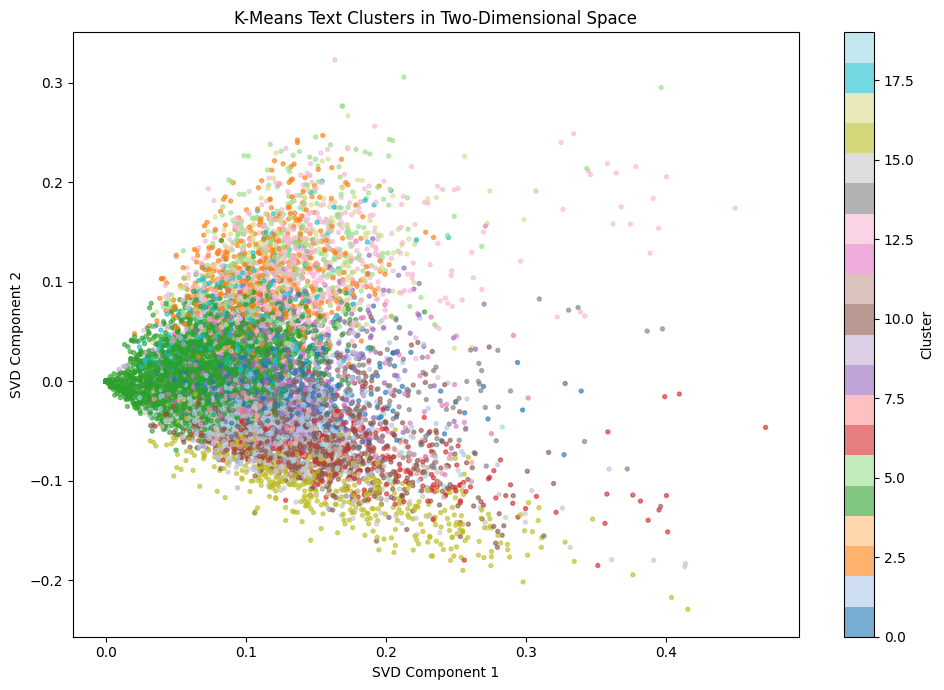

In [17]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_svd_2d[:, 0],
    X_svd_2d[:, 1],
    c=train_clusters,
    cmap="tab20",
    s=8,
    alpha=0.6
)
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("K-Means Text Clusters in Two-Dimensional Space")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


### t-SNE visualization
For an additional nonlinear view, I first reduce the TF-IDF data to 50 SVD components and then run t-SNE on a reproducible sample of 2,000 documents.


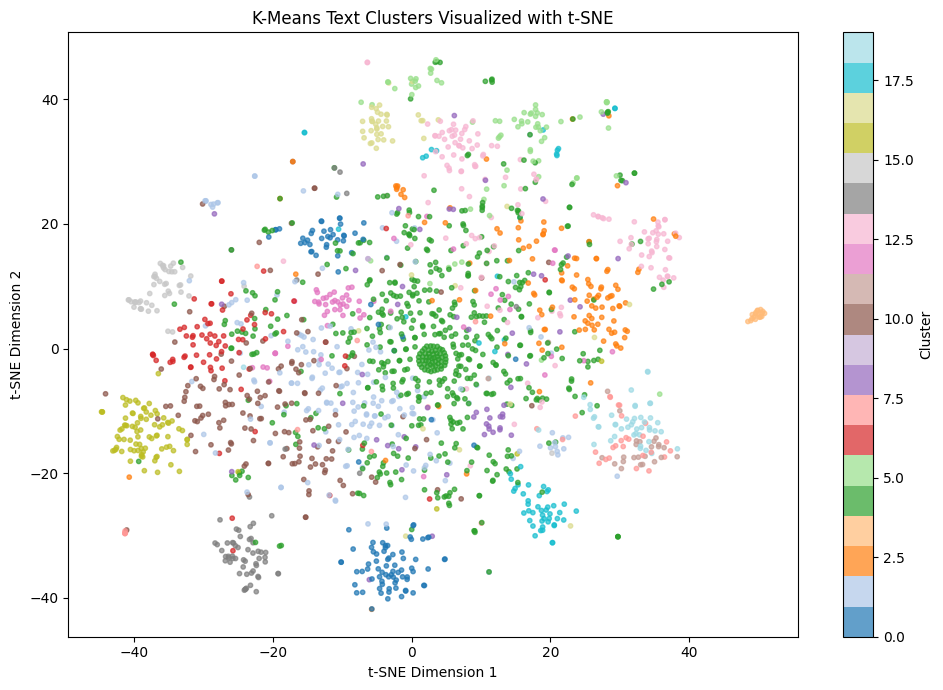

In [18]:
sample_size = min(2000, X_train_tfidf.shape[0])
tsne_ids = np.random.RandomState(42).choice(
    X_train_tfidf.shape[0], sample_size, replace=False
)

svd_50 = TruncatedSVD(n_components=50, random_state=42)
X_reduced_50 = svd_50.fit_transform(X_train_tfidf[tsne_ids])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000
)
X_tsne = tsne.fit_transform(X_reduced_50)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=train_clusters[tsne_ids],
    cmap="tab20",
    s=10,
    alpha=0.7
)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("K-Means Text Clusters Visualized with t-SNE")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


## 6. Final Answers and Conclusion

### How was the text prepared?
I converted documents to lowercase, removed punctuation and numbers, normalized whitespace, tokenized the text through Scikit-learn's vectorizers and removed English stopwords.

### What is the difference between Bag of Words and TF-IDF?
Bag of Words records word frequencies. TF-IDF also considers how widely a term appears across documents, so words that are more distinctive to particular documents receive greater importance.

### Why did I use TF-IDF for clustering?
I used TF-IDF because it reduces the influence of very common terms and emphasizes words that are more informative for distinguishing topics.

### What did K-Means discover?
K-Means grouped documents according to similarities in their TF-IDF representations. I interpreted the groups by examining the highest-weighted terms in each cluster.

### How did I evaluate the model?
I used the silhouette score to assess cohesion and separation. I also used the known newsgroup labels after clustering to calculate the Adjusted Rand Index as an external validation measure.

### Can the model handle unseen documents?
Yes. I transform new documents with the fitted TF-IDF vectorizer and use `kmeans.predict()` to assign them to one of the learned clusters.

### What did the visualization show?
The SVD and t-SNE plots provide simplified two-dimensional views of the high-dimensional text data. Some topic groups can separate visibly, while others overlap because many newsgroup discussions share vocabulary and themes.

### Conclusion
This project showed me how unstructured text can be converted into numerical representations and explored with unsupervised learning. Bag of Words provided a simple frequency-based representation, while TF-IDF gave a more useful representation for topic clustering. K-Means discovered groups based on vocabulary patterns without being given category labels. Cluster keywords, validation measures and dimensionality-reduction plots helped me interpret the results, while the test-set experiment demonstrated how the fitted model can assign unseen documents to established clusters.
